# 第 10 章 · MAE Masking 代码实验

[章节网页](../ch10.html)

## 运行内容

- 切分 patch
- 随机 mask
- 绘制重建图

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 把 8x8 图像切成 2x2 patch token。
vit_image = np.arange(64).reshape(8, 8)
patch_size = 2
patches = vit_image.reshape(4, patch_size, 4, patch_size).swapaxes(1, 2)
patch_tokens = patches.reshape(-1, patch_size * patch_size)

patch_df = pd.DataFrame(patch_tokens, columns=["p00", "p01", "p10", "p11"])
patch_df.insert(0, "patch_id", range(len(patch_df)))
display(patch_df.head(8))

,patch_id,p00,p01,p10,p11
0,0,0,1,8,9
1,1,2,3,10,11
2,2,4,5,12,13
3,3,6,7,14,15
4,4,16,17,24,25
5,5,18,19,26,27
6,6,20,21,28,29
7,7,22,23,30,31


## 1. Mask

In [3]:
# MAE masking：随机遮住一部分 patch，只保留可见 token。
rng = np.random.default_rng(4)
num_patches = len(patch_tokens)
mask_ratio = 0.5
visible_ids = np.sort(rng.choice(num_patches, size=int(num_patches * (1 - mask_ratio)), replace=False))
masked_ids = np.array([idx for idx in range(num_patches) if idx not in set(visible_ids)])

mae_df = pd.DataFrame({
    "patch_id": range(num_patches),
    "状态": ["可见" if idx in set(visible_ids) else "mask" for idx in range(num_patches)],
})
display(mae_df)

,patch_id,状态
0,0,mask
1,1,可见
2,2,mask
3,3,mask
4,4,mask
5,5,mask
6,6,可见
7,7,mask
8,8,mask
9,9,可见


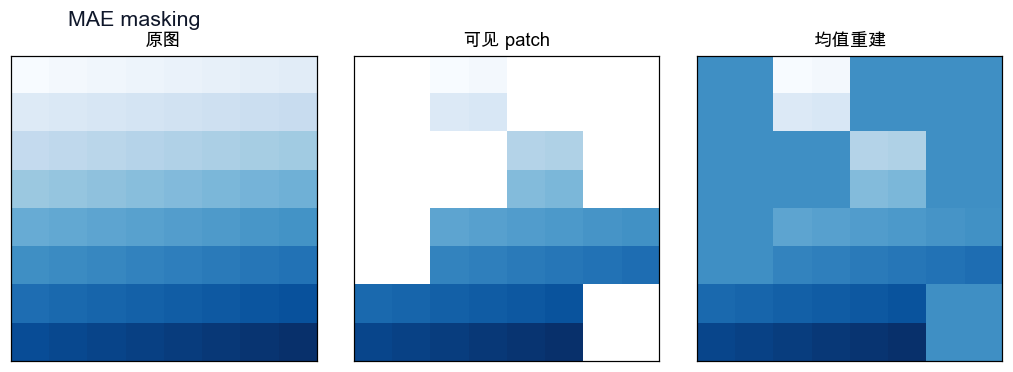

In [4]:
# 绘制 mask 图像和均值重建图像。
masked_image = vit_image.astype(float).copy()
recon_image = vit_image.astype(float).copy()
visible_mean = patch_tokens[visible_ids].mean()

for patch_id in masked_ids:
    row = patch_id // 4
    col = patch_id % 4
    masked_image[row * 2:(row + 1) * 2, col * 2:(col + 1) * 2] = np.nan
    recon_image[row * 2:(row + 1) * 2, col * 2:(col + 1) * 2] = visible_mean

fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.4))
for ax, data, title in zip(axes, [vit_image, masked_image, recon_image], ["原图", "可见 patch", "均值重建"]):
    ax.imshow(data, cmap="Blues")
    ax.set_title(title, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("MAE masking", x=0.08, ha="left", fontsize=14, fontweight="bold", color="#0f172a")
plt.tight_layout()
plt.show()